<sup>This notebook is originally from https://github.com/UCLIMgroup/UCLIM0_data_directory_structure and licensed for reuse under [GPL-3.0 license].</sup>

# New Project
---

This notebook creates the directory and variables required for a new project. 

# DATA FOLDER
---

In [2]:
import os

import numpy as np 
import matplotlib.pyplot as plt

#cartopy
import cartopy 
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

IMPORTANT: Modify the file "path_to_data.txt" with the route to your data folder. This notebook will create new projects in that "path_to_data" directory.

In [3]:
#get main directory of the notebooks
cwd = os.getcwd()
os.chdir(cwd)

#create a variable with the path to the code (one folder back to cwd)
cwd_main = os.path.abspath(os.path.join(cwd, os.pardir))

# go to current location of script
os.chdir(cwd_main)
print("Verify the main directories of your code and projects")
print("Main code folder: ",cwd_main)

import config_tool as cfm

print("Data folder: ",cfm.cwd_data)

Verify the main directories of your code and projects
Main code folder:  c:\Users\engs2418\Documents\PhD\UCLIM\UCLIM0_data_directory_structure
Data folder:  C:\Users\engs2418\Documents\PhD\UCLIM\UCLIM_data


## Define name of city project to work
---

Define the name of the **`city`** (projectname) to upload/save all data during the workflow

In [4]:
#Introduce new city project: 
city= "Paris"

## Generation of the project directory
---

Creation of new directory for the new project **`city`**.

In [5]:
#go to data folder
os.chdir(cfm.cwd_data)

In [6]:
#add in the path cfm.cwd_data, add a new folder with the variable "city"
cwd_project = cfm.cwd_data + fr"\{city}"
print(cwd_project)

C:\Users\engs2418\Documents\PhD\UCLIM\UCLIM_data\Paris


In [7]:
#Check if project directory is created - if not - create
if os.path.exists(cwd_project):
    print("The directory already exists: ", cwd_project)
if not os.path.exists(cwd_project):

    os.makedirs(cwd_project)
    os.makedirs(cwd_project+r"\data")
    os.makedirs(cwd_project+r"\data\10_raw")
    os.makedirs(cwd_project+r"\data\10_raw\netatmo")
    os.makedirs(cwd_project+r"\data\10_raw\wunder")

    os.makedirs(cwd_project+r"\data\11_structured")
    os.makedirs(cwd_project+r"\data\12_metadata") #descriptive data about data - if used for ML, they will be features

    os.makedirs(cwd_project+r"\data\20_quality_control")
    os.makedirs(cwd_project+r"\data\21_gap_filling")

    os.makedirs(cwd_project+r"\data\30_generation_spatial")
    os.makedirs(cwd_project+r"\data\30_generation_temporal")

    os.makedirs(cwd_project+r"\data\40_analysis")

    os.makedirs(cwd_project+r"\data\50_application")


    os.makedirs(cwd_project+r"\results")
    os.makedirs(cwd_project+r"\results\10_raw")
    os.makedirs(cwd_project+r"\results\10_raw\netatmo")
    os.makedirs(cwd_project+r"\results\10_raw\wunder")

    os.makedirs(cwd_project+r"\results\11_structured")
    os.makedirs(cwd_project+r"\results\12_metadata")

    os.makedirs(cwd_project+r"\results\20_quality_control")
    os.makedirs(cwd_project+r"\results\21_gap_filling")

    os.makedirs(cwd_project+r"\results\30_generation_spatial")
    os.makedirs(cwd_project+r"\results\30_generation_temporal")

    os.makedirs(cwd_project+r"\results\40_analysis")

    os.makedirs(cwd_project+r"\results\50_application")

    
    print("new directory created: ", cwd_project)

new directory created:  C:\Users\engs2418\Documents\PhD\UCLIM\UCLIM_data\Paris


## Create and modify config_project.py
---

Duplicate **`config_project.py`** file in your new project and modify the input data required for data extraction, pre-processing and analytics.

An example of **`config_project.py`** is available in z_project_data_example


## Import input data of the project - config_project.py 
---

Once created the new config_project.py file, open and check:

In [9]:
# go to current location of script
os.chdir(cwd_project)
print("Folder opened: ",cwd_project)

#import input data of the project
import config_project as cfp

Folder opened:  C:\Users\engs2418\Documents\PhD\UCLIM\UCLIM_data\Paris


In [10]:
#check input variables

print("city: ",cfp.city)
print("first date: ",cfp.first_date)
print("last date: ",cfp.last_date)
print("lat,long: ",cfp.lat,cfp.long)
print("plot: ",cfp.plot)

city:  Paris
first date:  01-01-2023 00:00
last date:  31-12-2023 23:00
lat,long:  48.83 2.349092294549077
plot:  75


## Explore and check config_project.py - location and extension (area for mapping)
---


Verification lat, long, and extension for UHI mapping

Definition of extent - frame for mapping

In [11]:
#get extent from config_project.py
extent = cfp.extent
print("Extent: ",extent)

Extent:  [1.8383434044450317, 2.859841184653122, 48.49279922998611, 49.167200770013885]


Visualisation of city extent using stadiamaps

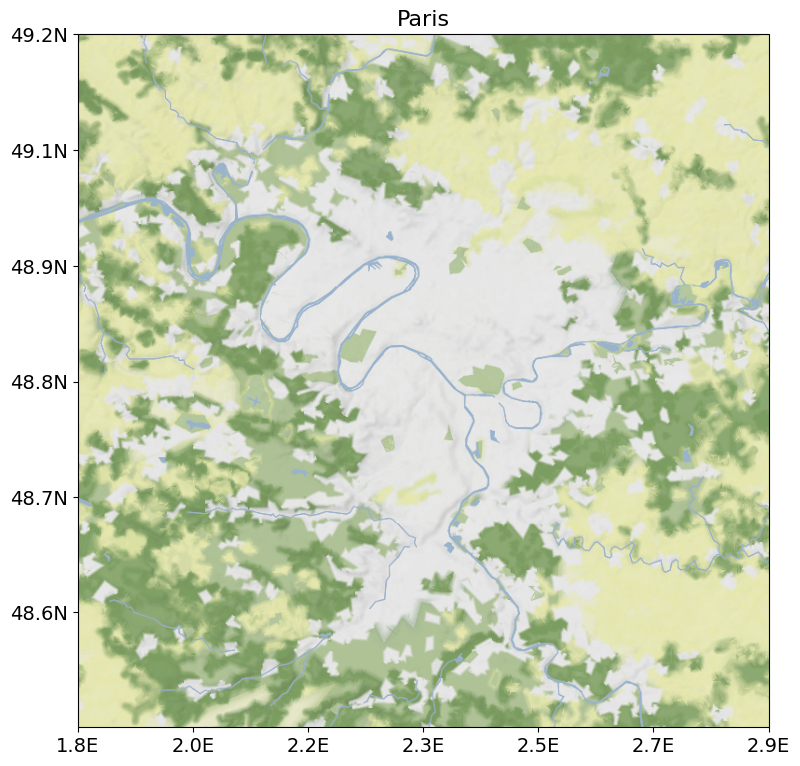

In [12]:

class StadiaMapsTiles(cimgt.GoogleTiles):
    def _image_url(self, tile):
         x,y,z = tile
         url = f"https://tiles.stadiamaps.com/tiles/stamen_terrain_background/{z}/{x}/{y}.png?api_key={STADIA_API_KEY}"
         #url = f"https://tiles.stadiamaps.com/tiles/alidade_smooth_dark/{z}/{x}/{y}.png?api_key={STADIA_API_KEY}"
         return url

# osm_img = cimgt.Stamen('terrain') # spoofed, downloaded street map  'terrain-background', 'terrain'
STADIA_API_KEY = '48325337-571e-4d38-8579-98a9fec2b872'
osm_img = StadiaMapsTiles() # spoofed, downloaded street map  'terrain-background', 'terrain'

fig = plt.figure(figsize=(12,9)) # open matplotlib figure
ax1 = plt.axes(projection=osm_img.crs) # project using coordinate reference system (CRS) of street map
ax1.set_title(f'{city}',fontsize=16)

ax1.set_extent(extent) # set extents

ax1.set_xticks(np.linspace(extent[0],extent[1],7),crs=ccrs.PlateCarree()) # set longitude indicators
ax1.set_yticks(np.linspace(extent[2],extent[3],7)[1:],crs=ccrs.PlateCarree()) # set latitude indicators
lon_formatter = LongitudeFormatter(number_format='0.1f',degree_symbol='',dateline_direction_label=True) # format lons
lat_formatter = LatitudeFormatter(number_format='0.1f',degree_symbol='') # format lats
ax1.xaxis.set_major_formatter(lon_formatter) # set lons
ax1.yaxis.set_major_formatter(lat_formatter) # set lats
ax1.xaxis.set_tick_params(labelsize=14)
ax1.yaxis.set_tick_params(labelsize=14)

scale = np.ceil(-np.sqrt(2)*np.log(np.divide((extent[1]-extent[0])/2.0,350.0))) # empirical solve for scale based on zoom
scale = (scale<20) and scale or 19 # scale cannot be larger than 19
ax1.add_image(osm_img, int(scale)) # add OSM with zoom specification

os.chdir(cfp.cwd_results_raw)
plt.savefig(f"UCLIM0_Extraction_area_{city}_figure1.jpg", format='jpg')
plt.show() # show plot

If the area to map is not adequate, modify the values of the following variables in **`config_project.py`** file: lat, long and plot.